# SWGO L07 Detector Optimization (Refactored)

All utility functions have been extracted into separate Python modules.
This notebook preserves the original optimization logic.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Standard library imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy
import warnings
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import colors
from matplotlib.colors import LogNorm, Normalize
from torch.utils.data import TensorDataset, DataLoader
import os
import gc

# Extracted module imports
from modules.generate_showers import GenerateShowers
from modules.shower_computation import ComputeShowerDetection
from modules.detector_response import GetCounts_differentiable, SmearN, TimeAverage_vectorized
from modules.geometry import Layouts
from modules.reconstruction import Reconstruction, NormalizeLabels, DenormalizeLabels, EarlyStopping
from modules.layout_optimization import LearnableXY, push_apart, symmetry_loss
from modules.utility_functions import reconstructability, U_PR, U_E, U_angle

output_dir = "./outputs/NN_Files_31_20k_new_model"
os.makedirs(output_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generate_new_data = not True

## Constants and Parameters

In [3]:
# Matrices used in shower parametrization
A = torch.tensor([[1, 1, 1, 1],[1, 2, 4, 8], [1, 3, 9, 27], [1, 4, 16, 64]], dtype=torch.float32)

# Constants
c0 = .29979  # Speed of light in [m / ns]
theta_max = np.pi * 65 / 180
log_01 = torch.tensor([np.log(.1)], dtype=torch.float32)
log_10 = torch.tensor([np.log(10)], dtype=torch.float32)
sqrt12 = torch.tensor([np.sqrt(12)], dtype=torch.float32)

# Tank Values
IntegrationWindow = 128.  # 128 ns integration window, SWGO default
sigma_time = 10.  # Time resolution assumed for the detectors
R_min = 2.
TankArea = 6.859 * np.pi  # Area for 19 hexagonal macro unit
TankRadius = np.sqrt(6.859)  # Radius of macro unit

# Background
Bgr_mu_per_m2 = 0.000001826 * IntegrationWindow
fluxB_m = torch.tensor([TankArea * Bgr_mu_per_m2])
Bgr_e_per_m2 = 0.000000200 * IntegrationWindow
fluxB_e = torch.tensor([TankArea * Bgr_e_per_m2])

# Sizes
Nunits = 90 # 500
n_rings = 5 #20
RelResCounts = .05

# Debug Parameters
largenumber = 1e13
epsilon = 1 / largenumber

# NN
Nevents = 20000#200000
Nvalidation = 2000#20000
Ntest = 300#3000

# Layout
SWGOopt = False

x_det, y_det = Layouts(n_detectors=Nunits, n_rings=n_rings, radius=3000, center=(0,0), device=device)


## Initialize Diffusion Model

In [4]:
generate_showers_instance = GenerateShowers(output_dir=output_dir, device=device)

## Helper: Wrap GenerateShowers with module dependencies

In [5]:
# Create wrapped versions that capture the global dependencies
import functools

_SmearN = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAverage = functools.partial(TimeAverage_vectorized,
                                  IntegrationWindow=IntegrationWindow,
                                  sigma_time=sigma_time)
_GetCounts = functools.partial(GetCounts_differentiable,
                                SmearN_fn=_SmearN,
                                fluxB_e=fluxB_e,
                                TimeAverage_vectorized_fn=_TimeAverage)

def generate_showers(x_det, y_det, log=False, number_of_showers=1, device=device, use_cache=False):
    return ComputeShowerDetection(x_det, y_det, generate_showers_instance, _GetCounts,
                           log=log, number_of_showers=number_of_showers, device=device, 
                           use_cache=use_cache, output_dir=output_dir)

## Visualize Initial Layout

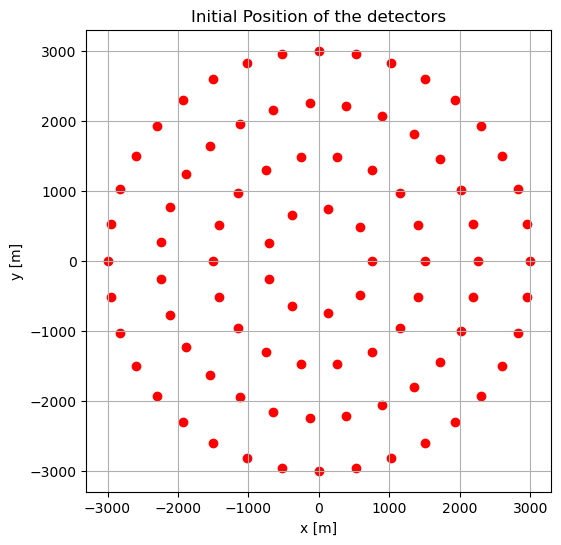

In [6]:
plt.figure(figsize=[6, 6])
plt.scatter(x_det.cpu().detach(), y_det.cpu().detach(), color="red")
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Initial Position of the detectors")
# plt.xlim((-50, 650))
# plt.ylim((-350, 350))
plt.show()

## Generate and Visualize a Single Shower

Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_10.pt


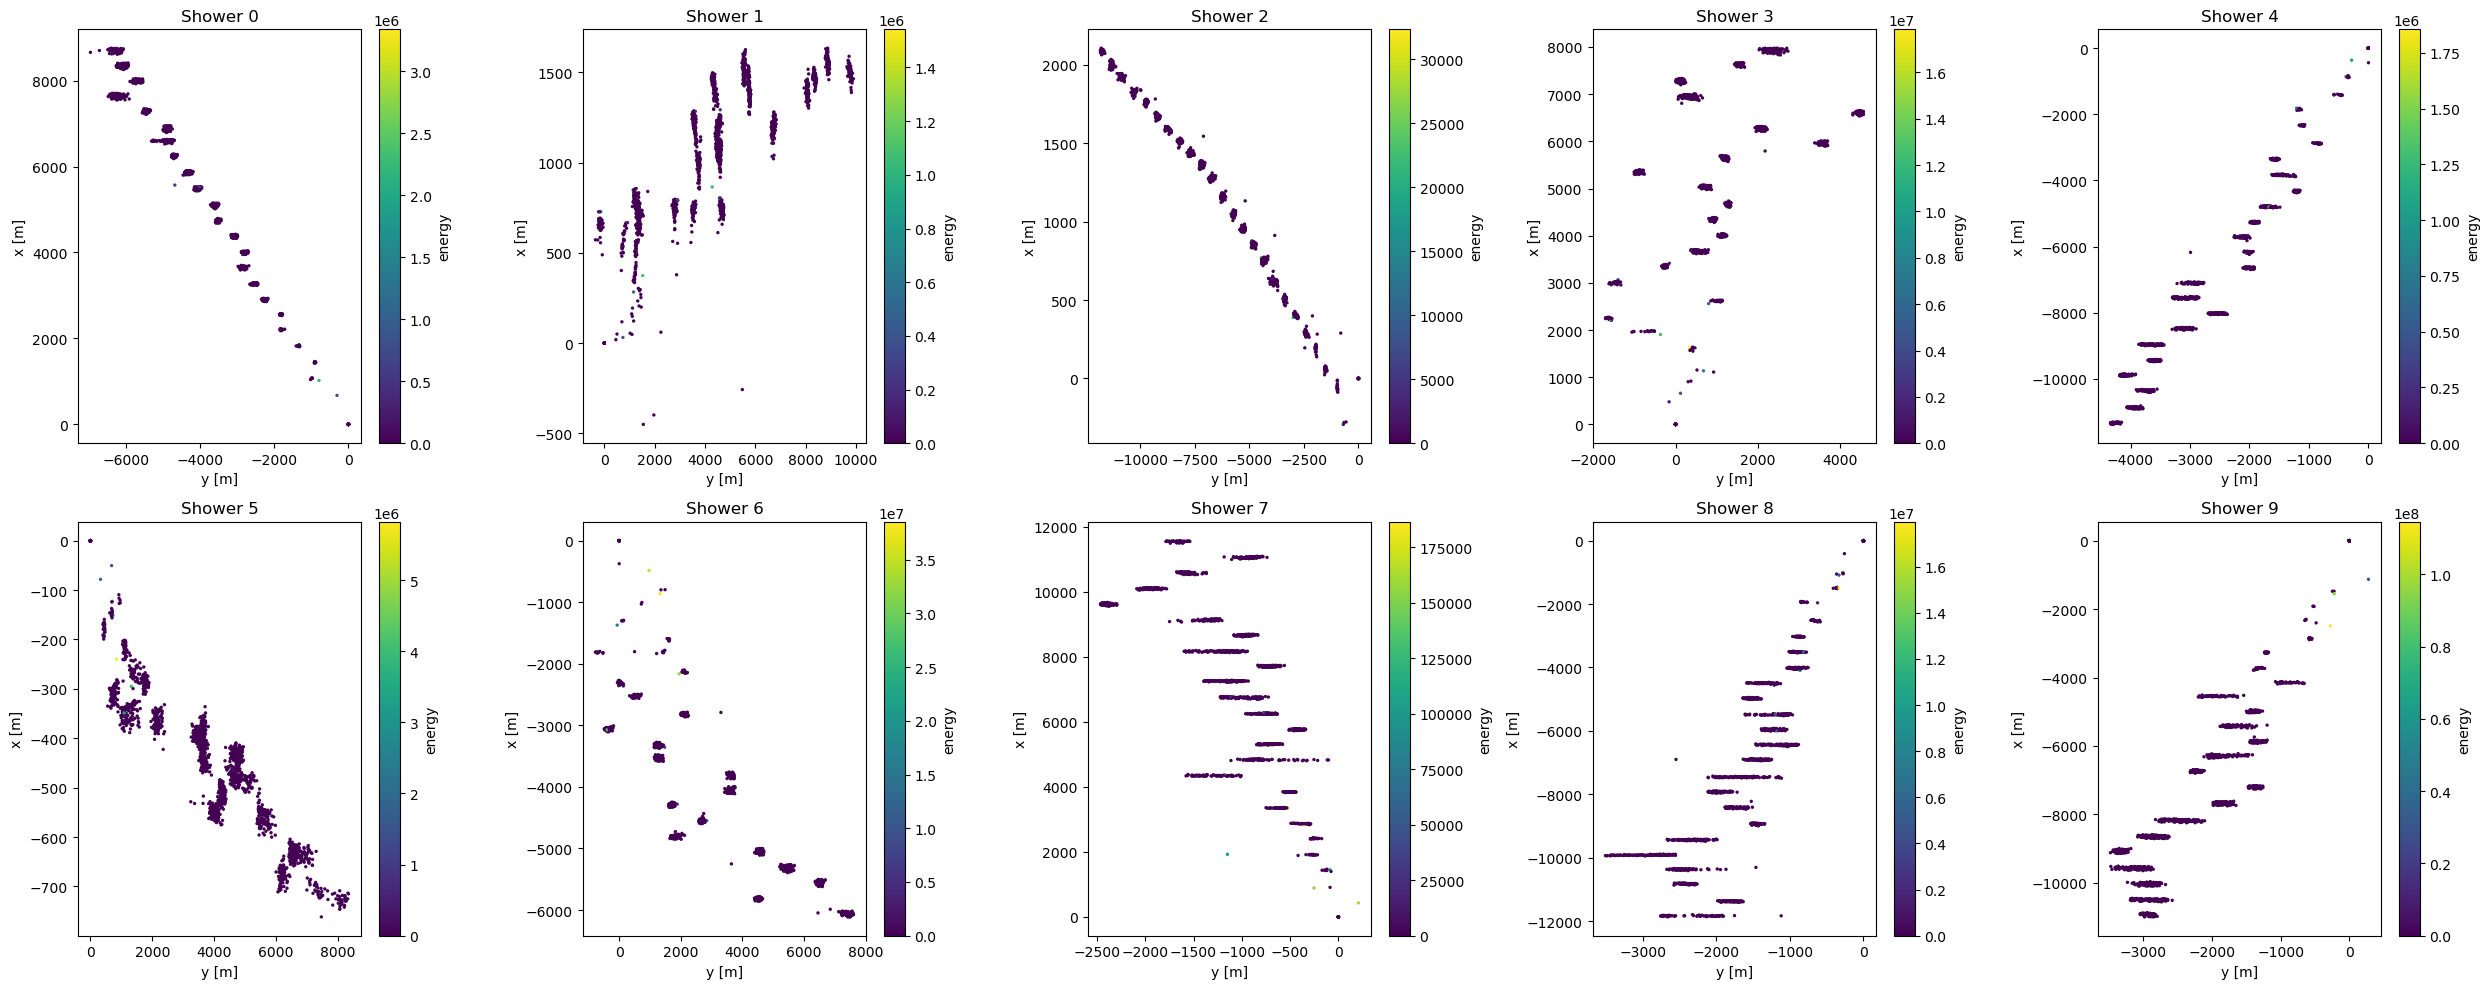

In [7]:
SWGOopt = False
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, labels = generate_showers(x_det, y_det, True, number_of_showers=10, use_cache=True)

In [8]:
print("N:", N.shape)
print("T:", T.shape)
print("X0:", X0)
print("Y0:", Y0)
print("E:", energy.shape)

N: torch.Size([10, 90])
T: torch.Size([10, 90])
X0: tensor([ 3454.2593,   744.0483,   732.7739,  3145.4587, -4997.6113,  -268.6878,
        -2129.8311,  3779.6089, -4107.5181, -2668.2026], device='cuda:0')
Y0: tensor([-2556.0125,  2223.2642, -4437.5298,   400.1859, -1827.0586,  1508.8705,
         1344.0685,  -610.6858,  -969.4191,  -531.1315], device='cuda:0')
E: torch.Size([10])


In [9]:
N[0]

tensor([2.1658e+05, 2.6027e+02, 1.8946e-02, 7.2011e-06, 5.6932e-07, 3.0694e-05,
        1.7471e-01, 1.9435e+03, 5.2569e+05, 1.0587e+02, 1.8244e-01, 6.7768e-05,
        5.9606e-09, 3.8254e-13, 5.7396e-17, 5.8225e-20, 9.1717e-22, 3.7011e-22,
        4.2687e-21, 1.0477e-18, 2.8180e-15, 3.2826e-11, 8.0902e-06, 4.7136e+00,
        3.7612e+04, 1.4223e+06, 1.8448e+05, 4.0599e-03, 3.7482e-09, 5.3976e-14,
        1.4444e-17, 1.4752e-21, 9.4158e-26, 6.3228e-30, 7.4980e-34, 2.5561e-37,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.9244e-38, 5.6811e-35, 3.6479e-31, 1.7028e-26, 1.6775e-19, 5.9093e-13,
        2.2215e-07, 7.4528e-02, 1.1060e+04, 2.5032e+06, 6.1489e+05, 2.2677e+02,
        2.8283e-11, 1.5557e-18, 1.2472e-25, 1.1905e-32, 2.5204e-36, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+

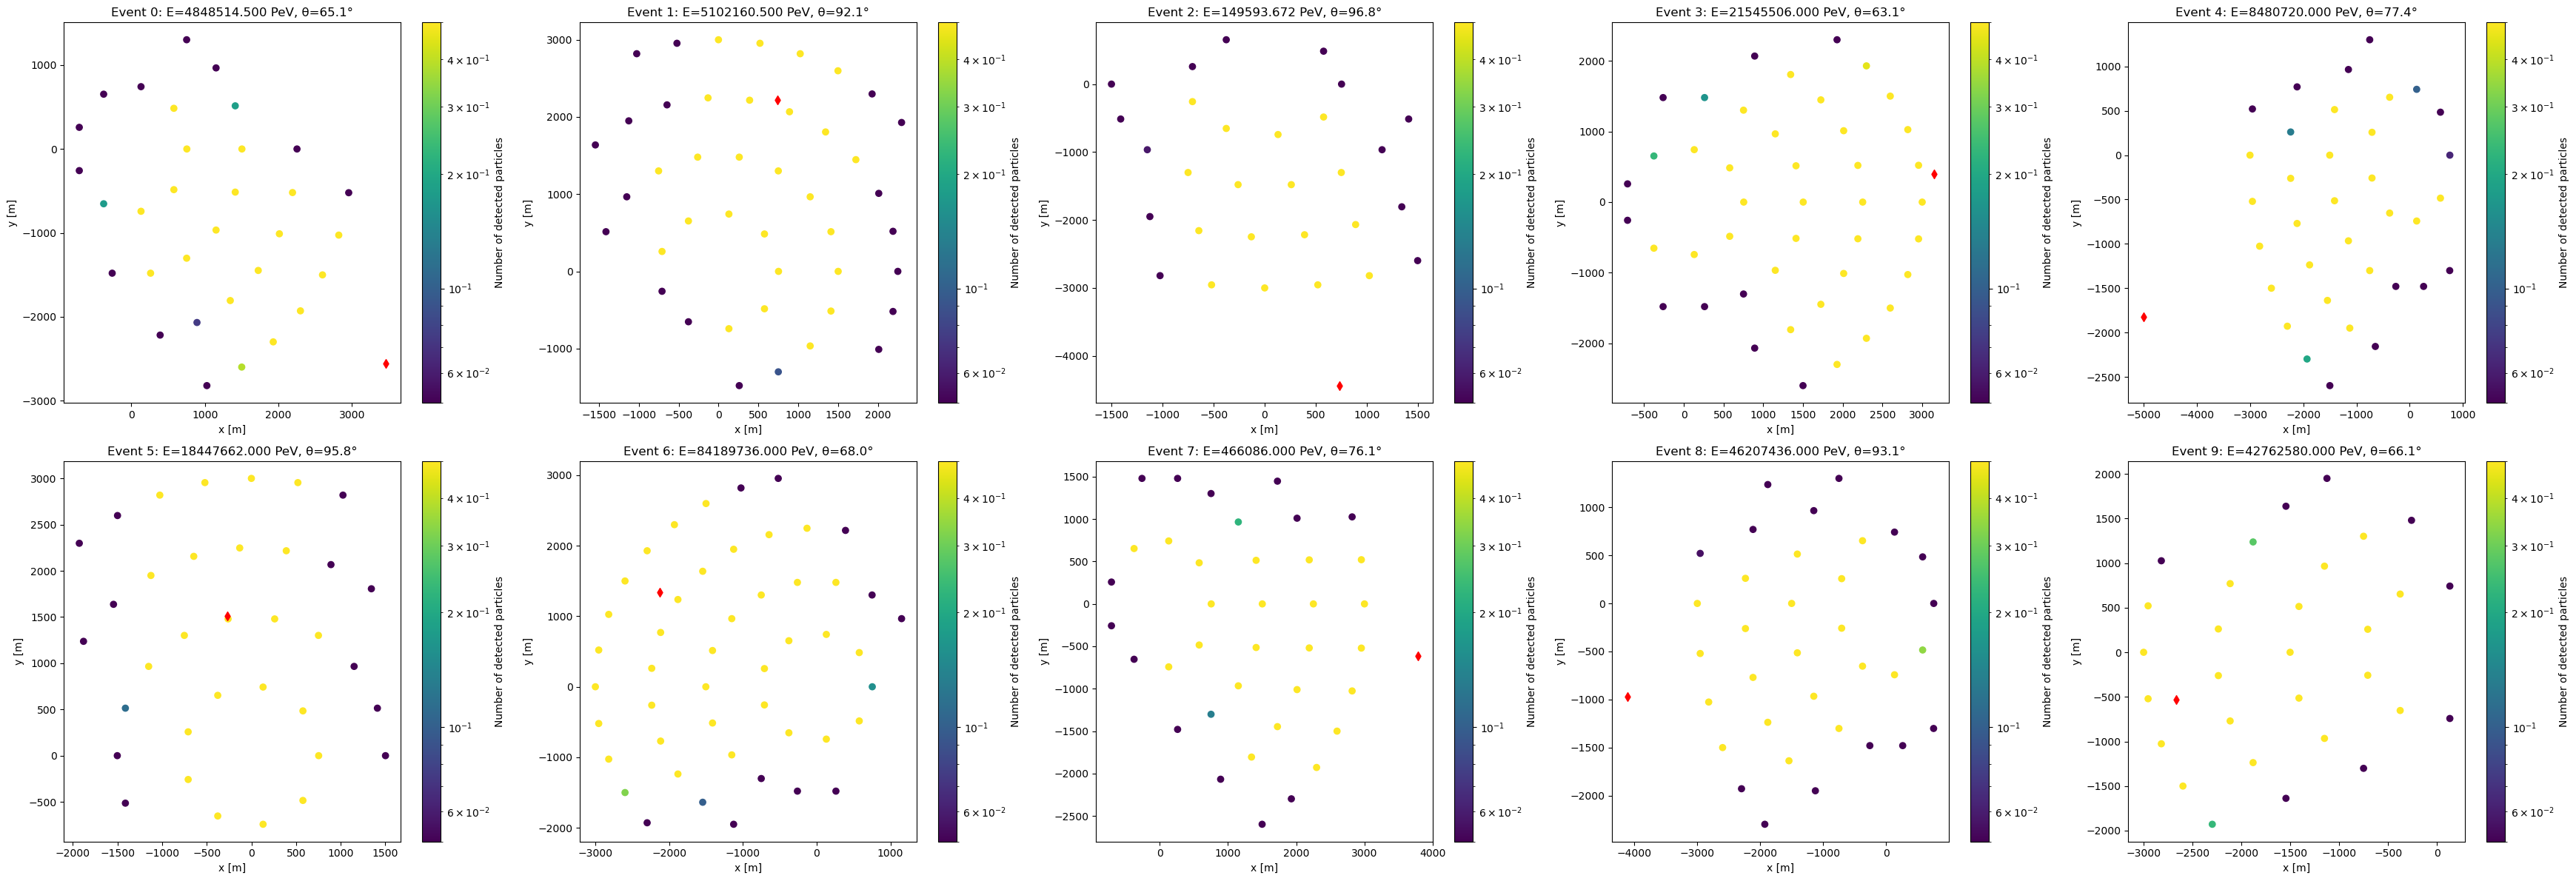

In [10]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    idx = torch.where(N_tmp >= 5e-9)[0]
    norm = LogNorm(vmin=5e-2, vmax=5e-1)

    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=N_tmp[idx].detach().cpu(), cmap="viridis", norm=norm)
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Number of detected particles')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    # axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

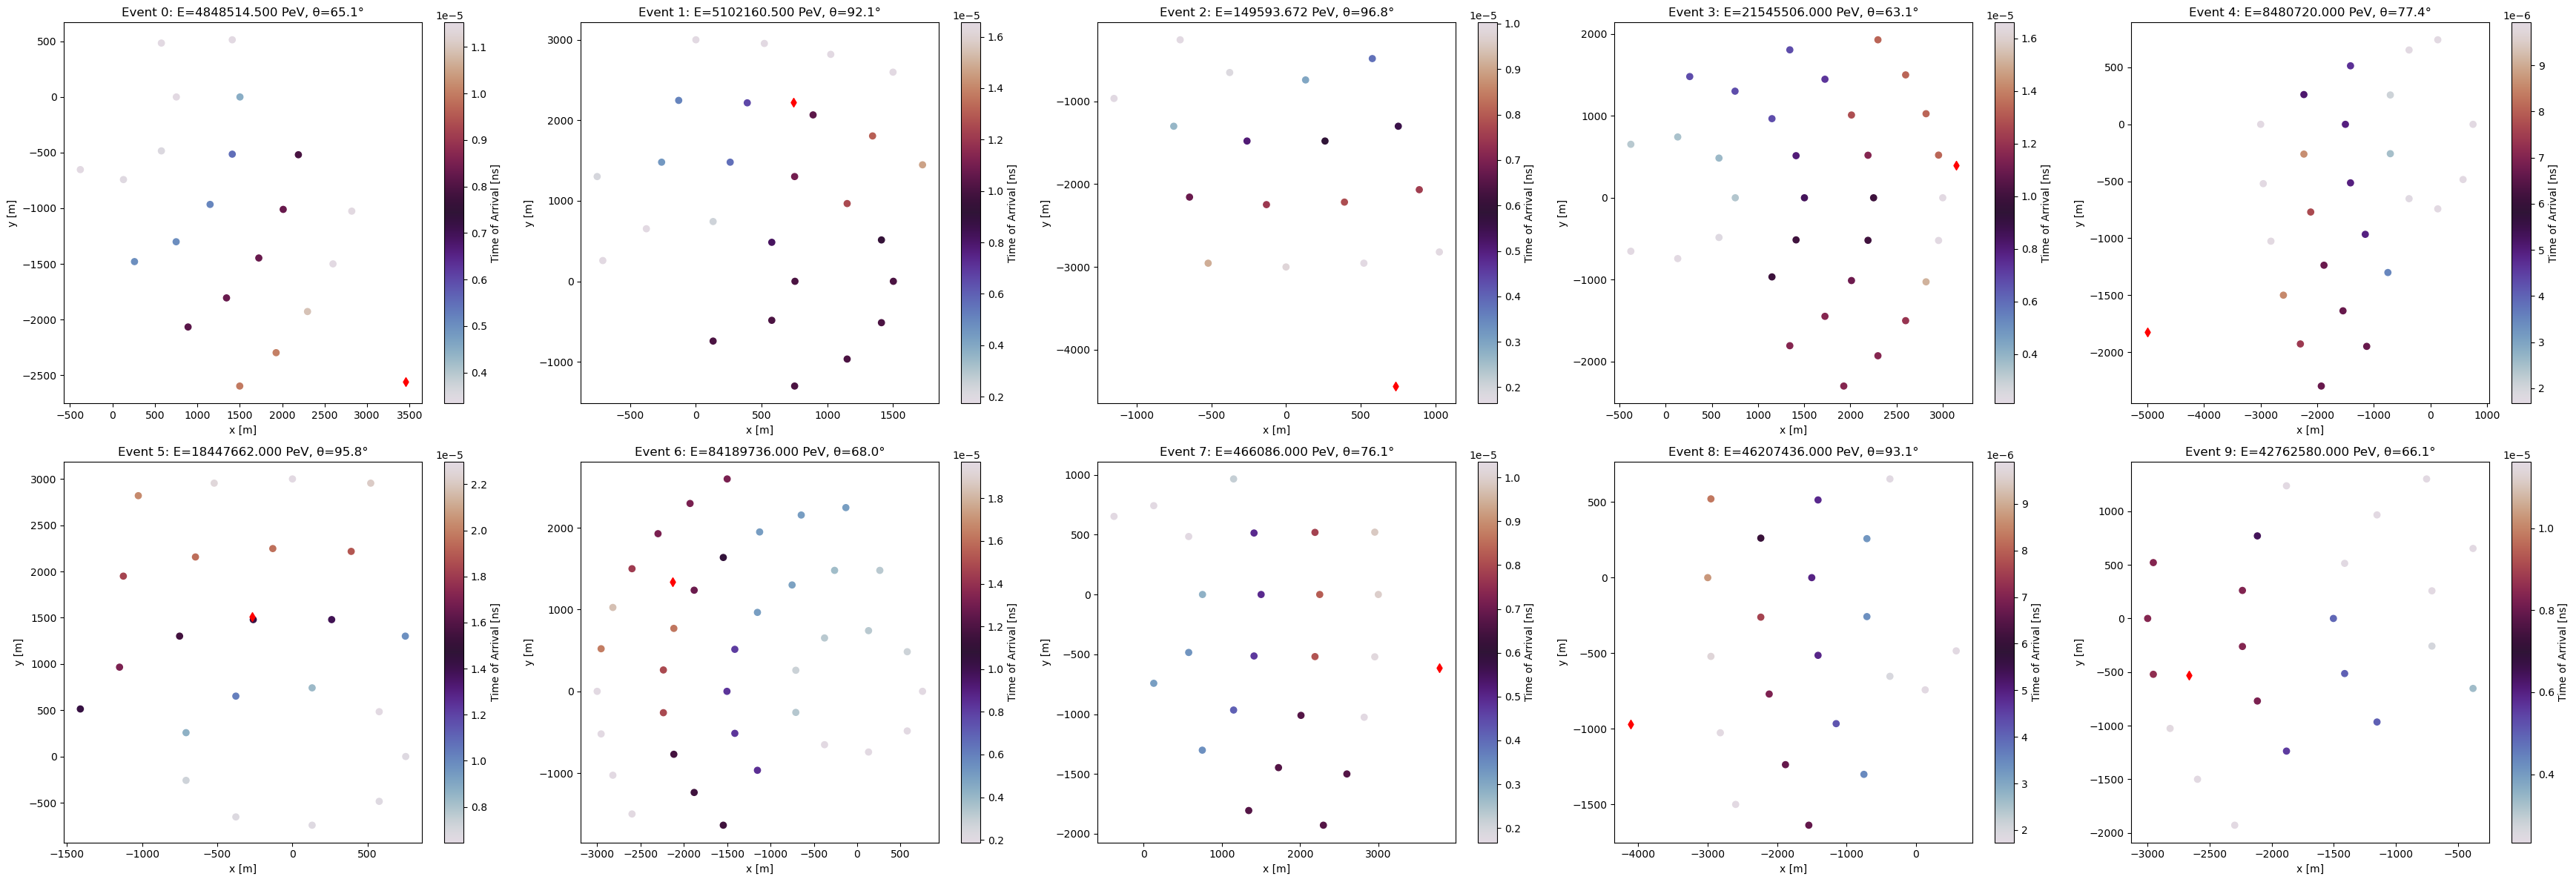

In [11]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-2)[0]
    from matplotlib.colors import SymLogNorm
    # norm = SymLogNorm(linthresh=1, vmin=-1, vmax=1)


    scatter = axes[i].scatter(x_det[idx].detach().cpu(), y_det[idx].detach().cpu(), c=T_tmp[idx].detach().cpu(), cmap="twilight")
    
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Time of Arrival [ns]')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    # axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

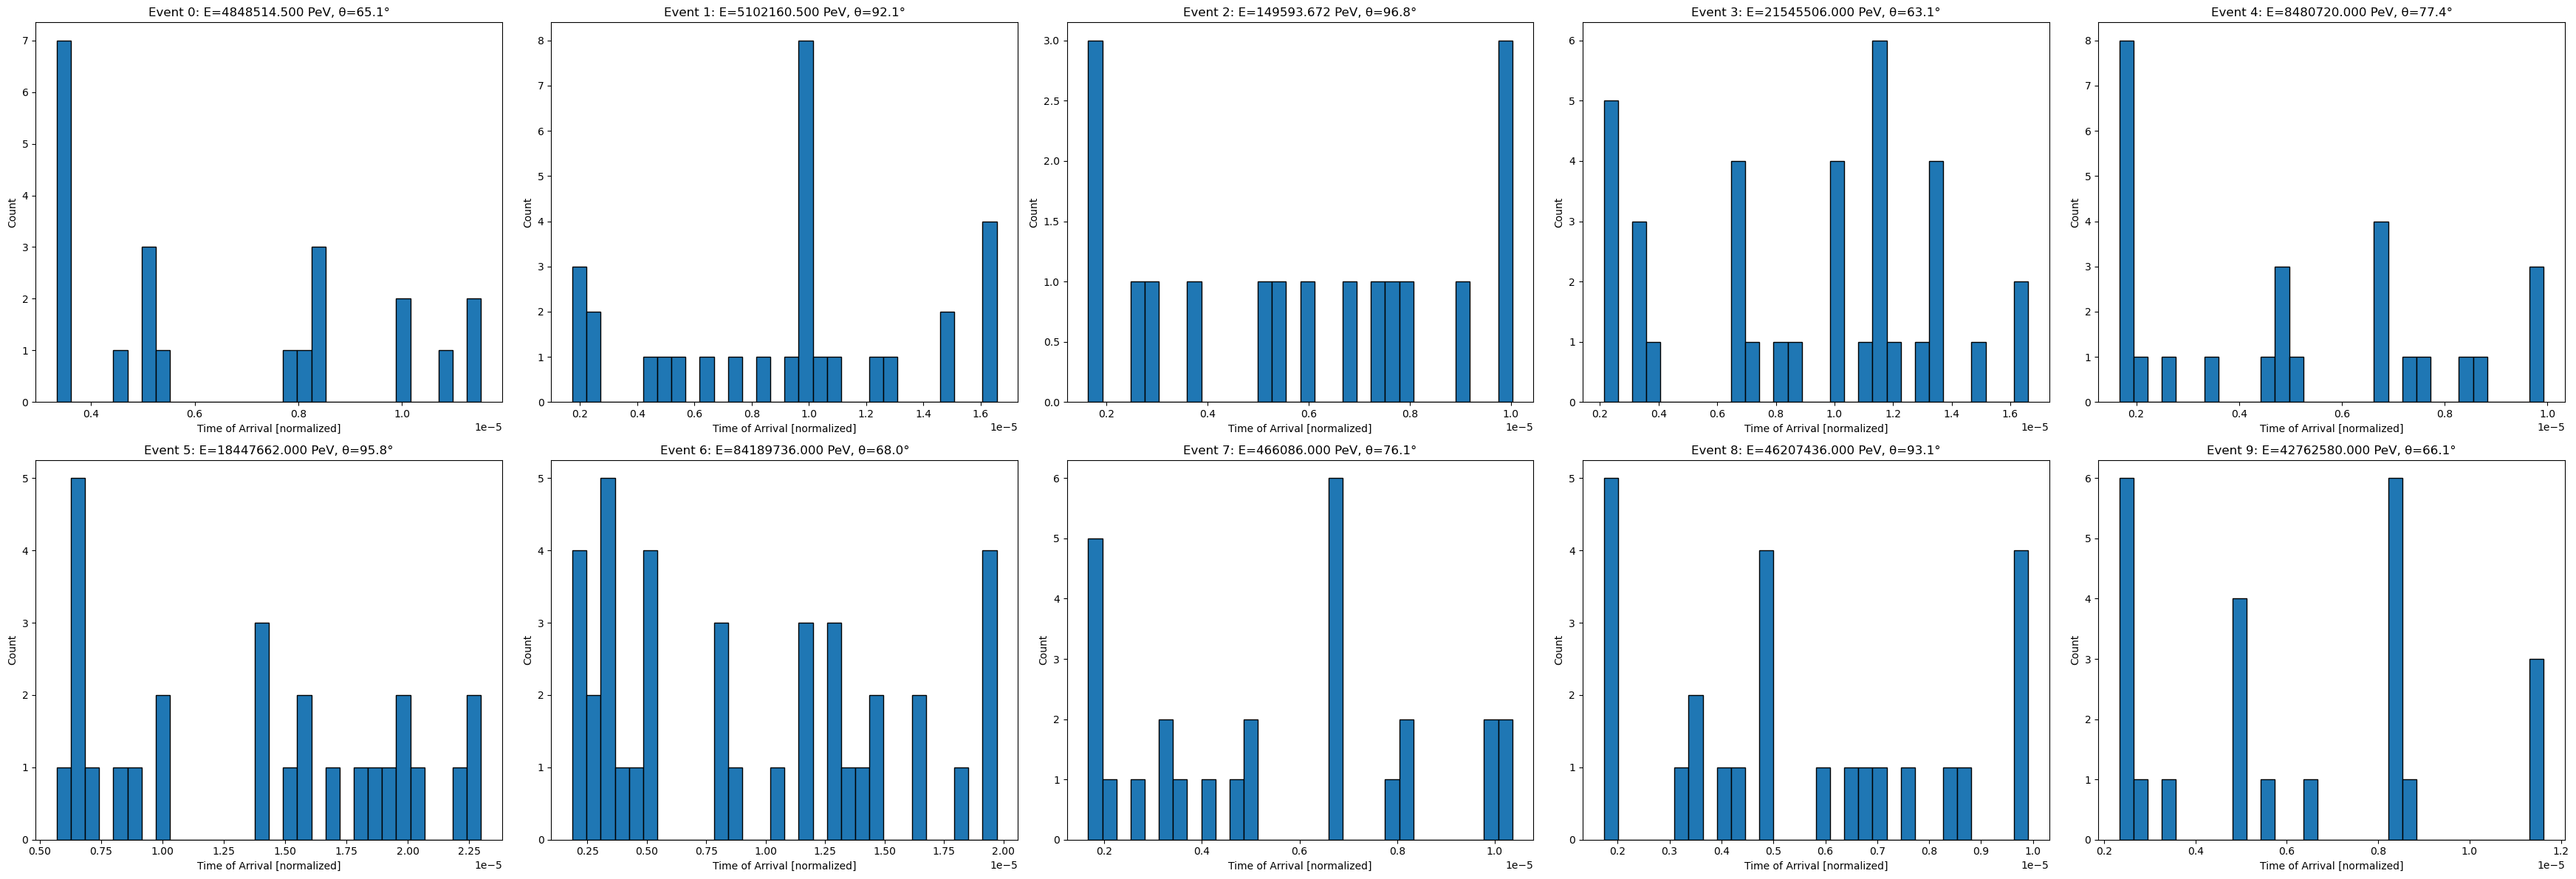

In [12]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-3)[0]
    axes[i].hist(T_tmp[idx].detach().cpu().numpy(), bins=30, edgecolor='black')
    axes[i].set_xlabel("Time of Arrival [normalized]")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Generate Training Data

In [13]:
print(f"energy.min(): {energy.min()}, energy.max(): {energy.max()}")
print(f"theta.min(): {th.min()}, theta.max(): {th.max()}")
print(f"phi.min(): {ph.min()}, phi.max(): {ph.max()}")

energy.min(): 149593.671875, energy.max(): 84189736.0
theta.min(): 1.101935863494873, theta.max(): 1.689335584640503
phi.min(): -3.118431806564331, phi.max(): 2.143275737762451


In [14]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Nevents, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nevents, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nevents, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    os.makedirs(output_dir, exist_ok=True)
    torch.save(inputs, f"{output_dir}/inputs.pt")
    torch.save(labels, f"{output_dir}/labels.pt")

CPU times: user 5 μs, sys: 1e+03 ns, total: 6 μs
Wall time: 11.2 μs


## Generate Validation Data

In [15]:
%%time

if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Nvalidation, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Nvalidation, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Nvalidation, -1)

    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_val = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_val = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_val, f"{output_dir}/inputs_val.pt")
    torch.save(labels_val, f"{output_dir}/labels_val.pt")

CPU times: user 4 μs, sys: 0 ns, total: 4 μs
Wall time: 6.68 μs


## Generate Test Data

In [16]:
if generate_new_data:
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det, y_det, False, number_of_showers=Ntest, use_cache=True)

    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x_det_exp = x_det.unsqueeze(0).expand(Ntest, -1)
    y_det_exp = y_det.unsqueeze(0).expand(Ntest, -1)


    x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

    inputs_test = torch.stack([x_det_exp, y_det_exp, N, T, x0_exp, y0_exp], dim=2).float()
    labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

    torch.save(inputs_test, f"{output_dir}/inputs_test.pt")
    torch.save(labels_test, f"{output_dir}/labels_test.pt")

## Load Cached Data (optional)

In [17]:
inputs = torch.load(f"{output_dir}/inputs.pt")
labels = torch.load(f"{output_dir}/labels.pt")
inputs_val = torch.load(f"{output_dir}/inputs_val.pt")
labels_val = torch.load(f"{output_dir}/labels_val.pt")
inputs_test = torch.load(f"{output_dir}/inputs_test.pt")
labels_test = torch.load(f"{output_dir}/labels_test.pt")

In [18]:
# # switch normaliation value

# labels_denorm = DenormalizeLabels(labels[:,0], labels[:,1], labels[:,2], theta_max = torch.pi*65/180)
# labels_renorm = NormalizeLabels(labels_denorm[0], labels_denorm[1], labels_denorm[2])
# labels_renorm = torch.stack(labels_renorm, dim=1)

# labels_val_denorm = DenormalizeLabels(labels_val[:,0], labels_val[:,1], labels_val[:,2], theta_max = torch.pi*65/180)
# labels_val_renorm = NormalizeLabels(labels_val_denorm[0], labels_val_denorm[1], labels_val_denorm[2])
# labels_val_renorm = torch.stack(labels_val_renorm, dim=1)


# labels_test_denorm = DenormalizeLabels(labels_test[:,0], labels_test[:,1], labels_test[:,2], theta_max = torch.pi*65/180)
# labels_test_renorm = NormalizeLabels(labels_test_denorm[0], labels_test_denorm[1], labels_test_denorm[2])
# labels_test_renorm = torch.stack(labels_test_renorm, dim=1)

# # labels_renorm.shape, labels_val_renorm.shape, labels_test_renorm.shape

# torch.save(labels_renorm, f"{output_dir}/labels.pt")
# torch.save(labels_val_renorm, f"{output_dir}/labels_val.pt")
# torch.save(labels_test_renorm, f"{output_dir}/labels_test.pt")

## Train Reconstruction NN

In [19]:
model = Reconstruction(
    num_detectors=Nunits,
    ).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [20]:
# Per-feature normalization stats (computed from training data only)
input_mean = inputs.mean(dim=(0, 1))  # [6]
input_std  = inputs.std(dim=(0, 1))   # [6]
input_std[input_std < 1e-8] = 1.0

# Normalize cached datasets
inputs     = (inputs - input_mean) / input_std
inputs_val = (inputs_val - input_mean) / input_std
inputs_test = (inputs_test - input_mean) / input_std

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=False, num_workers=0)

In [21]:
%%time
if generate_new_data:
    val_losses = []
    losses = []
    early_stopper = EarlyStopping()

    for num_epoch in range(1000):
        epoch_loss = 0
        total_batch = 0
        
        for batch_inputs, batch_labels in dataloader:
            train_x = batch_inputs.flatten(start_dim=1, end_dim=2).to(device)
            train_y = batch_labels.to(device)
            
            outputs = model(train_x)
            loss = criterion(outputs, train_y)
            epoch_loss += loss.item()
            total_batch += 1

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        val_x = inputs_val.flatten(start_dim=1, end_dim=2).to(device)
        val_y = labels_val.to(device)

        model.eval()
        with torch.no_grad():
            val_output = model(val_x)
            val_loss = criterion(val_output, val_y)
        
        val_losses.append(val_loss.item())
        early_stopper(val_loss)

        if (num_epoch + 1) % 100 == 0:
            print(f"Training is {int((num_epoch + 1) / 10)}% done, with Loss = {val_loss:.2f}")

        losses.append(epoch_loss / total_batch)

    plt.plot(np.arange(1, len(losses) + 1), losses, color="blue", label="Training Loss")
    plt.plot(np.arange(1, len(val_losses) + 1), val_losses, color="red", label="Validation Loss")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid()

    torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")


CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 5.48 μs


## Evaluate Reconstruction

In [22]:
model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))

model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [23]:

# x_pred = outputs[:, 0]
# y_pred = outputs[:, 1]
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])
E_lb, theta_lb, phi_lb = DenormalizeLabels(labels_test[:, 0], labels_test[:, 1], labels_test[:, 2])

E_p,    E_r     =   E_pred,       E_lb
Th_p,   Th_r    =   theta_pred,   theta_lb
Ph_p,   Ph_r    =   phi_pred,     phi_lb

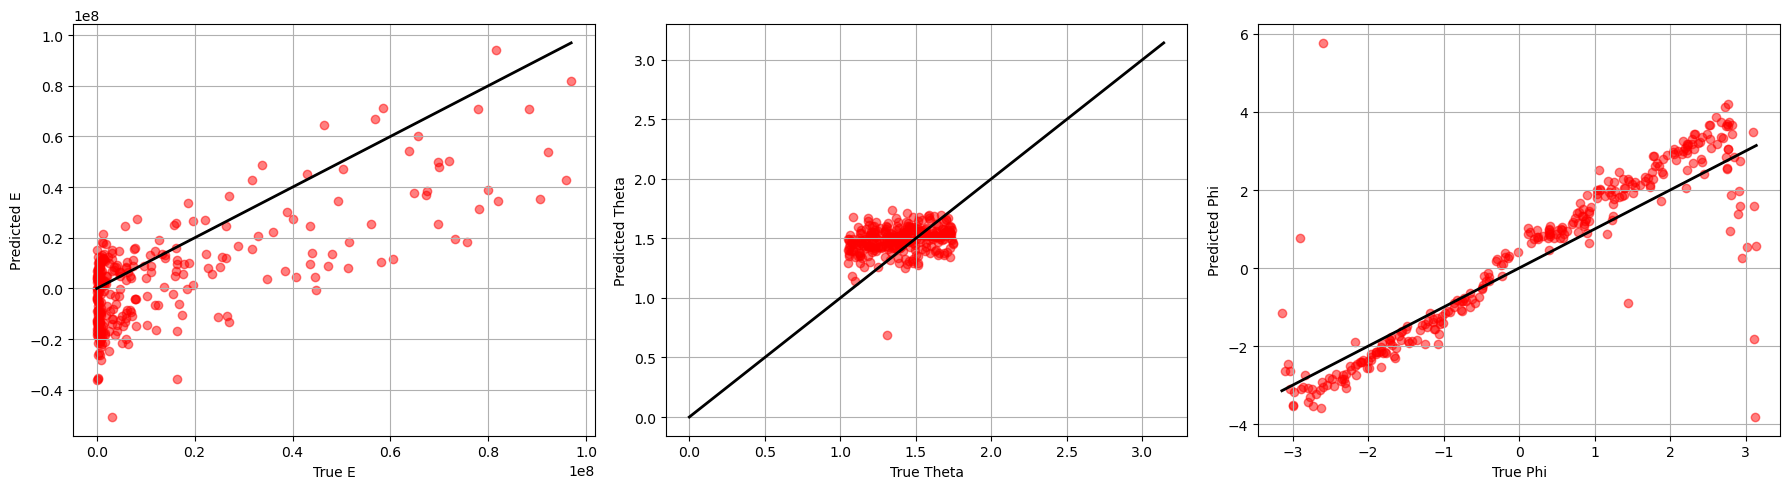

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


## Load/Initialize Model for Optimization

In [25]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

model = Reconstruction(
    num_detectors=Nunits,
    ).to(device)

path = Path(f"{output_dir}/checkpoint.pth")
if path.exists():
    checkpoint = torch.load(f"{output_dir}/checkpoint.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Updated Weights are loaded")
else:
    model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
    print("Initial Weights are loaded")

Initial Weights are loaded


## Initialize Learnable Layout

In [26]:
e = 0
os.makedirs(f"{output_dir}/Python_Layout", exist_ok=True)

for i in range(1000):
    p_layout = Path(f"{output_dir}/Python_Layout/Layout_{i + 1}.txt")
    if p_layout.exists():
        data = np.loadtxt(p_layout)
        x_det = torch.tensor(data[:, 0], dtype=torch.float32)
        y_det = torch.tensor(data[:, 1], dtype=torch.float32)
        e = i + 1

if e > 0:
    print(f"Updated Layout {e} is initialized")
else:
    print("First Layout is initialized")

xy_module = LearnableXY(x_det, y_det, device=device)

First Layout is initialized


## Layout Optimization Loop

In [27]:
input_std = input_std.to(device)
input_mean = input_mean.to(device)

In [37]:
%%time

SWGOopt = True
optimizer = torch.optim.SGD(xy_module.parameters(), lr=10, momentum=.3)

if path.exists():
    checkpoint = torch.load(path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    num_epoch = checkpoint.get("epoch") + 1
    loss = checkpoint.get("loss")
    print(f"Optimizer is initialized from the last epoch {num_epoch}")
else:
    num_epoch = 0
    print("Optimizer is initialized")

# max_grad = 5. #10.
Nbatch = 500#1000

if num_epoch < 20:
    Nfinetune = 1250#2500
elif num_epoch >= 20:
    Nfinetune = 2500#5000

U_vals = []
U_th_vals = []
U_phi_vals = []
U_e_vals = []
U_pr_vals = []

for epoch in range(num_epoch, num_epoch + 100):
    x_det_opt, y_det_opt = xy_module()
    
    N_list, T_list, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_det_opt, y_det_opt, False, number_of_showers=Nbatch, use_cache=True)
    
    th = torch.atan2(sin_z, cos_z).to(device)
    ph = torch.atan2(sin_a, cos_a).to(device)

    X0 /= 5000
    Y0 /= 5000
    
    # detector locations            
    x_det_opt_exp = x_det_opt.unsqueeze(0).repeat(Nbatch, 1)
    y_det_opt_exp = y_det_opt.unsqueeze(0).repeat(Nbatch, 1)

    # shower centers    
    x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
    y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

    inputs_batch = torch.stack([x_det_opt_exp, y_det_opt_exp, N_list, T_list, x0_exp, y0_exp], dim=2).float()
    with torch.no_grad():
        input_mean[0] = inputs_batch[:, :, 0].mean()
        input_mean[1] = inputs_batch[:, :, 1].mean()
        input_std[0]  = inputs_batch[:, :, 0].std().clamp(min=1e-8)
        input_std[1]  = inputs_batch[:, :, 1].std().clamp(min=1e-8)

    inputs_batch_norm = (inputs_batch - input_mean) / input_std

    model.eval()
    preds_batch = model(inputs_batch_norm.view(Nbatch, -1))

    preds_e, preds_th, preds_phi = DenormalizeLabels(preds_batch[:, 0], preds_batch[:, 1], preds_batch[:, 2])

    # compute utility 
    r_score = reconstructability(inputs_batch[:, :, 2], reconstruct_threshold=10)
    U = (
        1e2    *   U_angle( preds_th, th, r_score ) + 
        1e2    *   U_angle( preds_phi, ph, r_score ) +
        1e3     *   U_E( preds_e, energy, r_score ) + 
        # 1e9*N_list.mean()
        # 1e9*preds_e.mean()
        5e5     *   U_PR( r_score ) 
    ) / 1e3

    # save utlity values for logging
    U_vals.append( U.item() )
    U_th_vals.append( 1e2 * U_angle( preds_th, th, r_score ).item() )
    U_phi_vals.append( 1e2 * U_angle( preds_phi, ph, r_score ).item() )
    U_e_vals.append( 1e3 * U_E( preds_e, energy, r_score ).item() )
    U_pr_vals.append( ( 5e5 * U_PR( r_score ) ).item() )

    print(f"Utility: {U:.2f}")

    # backpropagate loss
    Loss = -U
    Loss.backward()

    for name, p in xy_module.named_parameters():
        print(f"{name}: grad norm = {p.grad.norm().item() if p.grad is not None else 'None'}")

    # torch.nn.utils.clip_grad_norm_(xy_module.parameters(), max_norm=max_grad)
    optimizer.step()

    # with torch.no_grad():
    #     push_apart(xy_module, min_dist=2 * TankRadius)
    
    optimizer.zero_grad()
    
    # Fine-tune NN every 5 epochs
    if (epoch + 1) % 5 == 0:
        
        model.zero_grad()
        print(f"Fine Tune at epoch {epoch + 1}")
        
        # Prepare data
        with torch.no_grad():
            x_det_ft, y_det_ft = xy_module()
            x_ft = x_det_ft.detach()
            y_ft = y_det_ft.detach()

            N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x_ft, y_ft, False, number_of_showers=Nfinetune, use_cache=True)
            
            theta = torch.atan2(sin_z, cos_z)
            phi = torch.atan2(sin_a, cos_a)
            
            energy_norm, theta_norm, phi_norm = NormalizeLabels(energy, theta, phi)
            X0 /= 5000
            Y0 /= 5000
            
            # normalized labels
            labels_finetune = torch.stack([ energy_norm, theta_norm, phi_norm], dim=1).float()
            
            # detector locations
            x_det_ft_exp = x_ft.unsqueeze(0).expand(Nfinetune, -1)
            y_det_ft_exp = y_ft.unsqueeze(0).expand(Nfinetune, -1)
            
            # shower centers
            x0_exp = X0.unsqueeze(1).expand(-1, Nunits)
            y0_exp = Y0.unsqueeze(1).expand(-1, Nunits)

            inputs_finetune = torch.stack([x_det_ft_exp, y_det_ft_exp, N, T, x0_exp, y0_exp], dim=2).float()
            
            input_mean[0] = inputs_finetune[:, :, 0].mean()
            input_mean[1] = inputs_finetune[:, :, 1].mean()
            input_std[0]  = inputs_finetune[:, :, 0].std().clamp(min=1e-8)
            input_std[1]  = inputs_finetune[:, :, 1].std().clamp(min=1e-8)

            inputs_finetune = (inputs_finetune - input_mean) / input_std

        # get model
        ReconstructionNN = model
        ReconstructionNN.train()
        criterion = nn.MSELoss()
        optimizerNN = torch.optim.Adam(ReconstructionNN.parameters(), lr=1e-6)
        
        # create training dataset
        ft_dataset = TensorDataset(inputs_finetune, labels_finetune)
        ft_dataloader = DataLoader(ft_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=0)

        # train NN for 5 sub-epochs
        for j in range(2):
            for inputs_ft, labels_ft in ft_dataloader:
                batch_size = inputs_ft.size(0)
                train_x = inputs_ft.view(batch_size, -1).to(device)
                train_y = labels_ft.view(batch_size, 3).to(device)
                outputs = ReconstructionNN(train_x)
                lossT = criterion(outputs, train_y)
                lossT.backward()
                optimizerNN.step()
                optimizerNN.zero_grad()

    torch.save({"epoch": epoch, "loss": Loss.cpu(), "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()}, f"{output_dir}/checkpoint.pth")
    
    np.savetxt(f"{output_dir}/Python_Layout/Layout_{epoch + 1}.txt",
               np.column_stack((x_det_opt.detach().cpu().numpy(), y_det_opt.detach().cpu().numpy())))

Optimizer is initialized from the last epoch 100
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_500.pt
Utility: 32425.55
x: grad norm = 25.735883712768555
y: grad norm = 18.32738494873047
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_500.pt
Utility: 34145.18
x: grad norm = 17.02088737487793
y: grad norm = 18.65125274658203
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_500.pt
Utility: 34246.46
x: grad norm = 13.775186538696289
y: grad norm = 12.969982147216797
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_500.pt
Utility: 34918.68
x: grad norm = 13.742194175720215
y: grad norm = 12.911977767944336
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_500.pt
Utility: 35366.05
x: grad norm = 15.166744232177734
y: grad norm = 19.915002822875977
Fine Tune at epoch 105
Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_

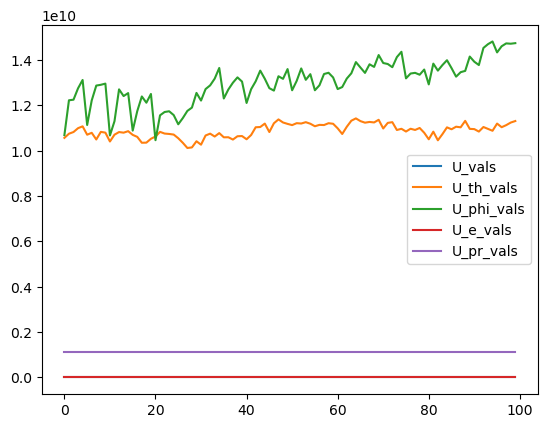

In [ ]:
plt.plot(U_vals, label='U_vals')
plt.plot([1000*u for u in U_th_vals], label='U_th_vals')
plt.plot([1000*u for u in U_phi_vals], label='U_phi_vals')
plt.plot(U_e_vals, label='U_e_vals')
plt.plot([100*u for u in U_pr_vals], label='U_pr_vals')
plt.legend()

## Visualize Results

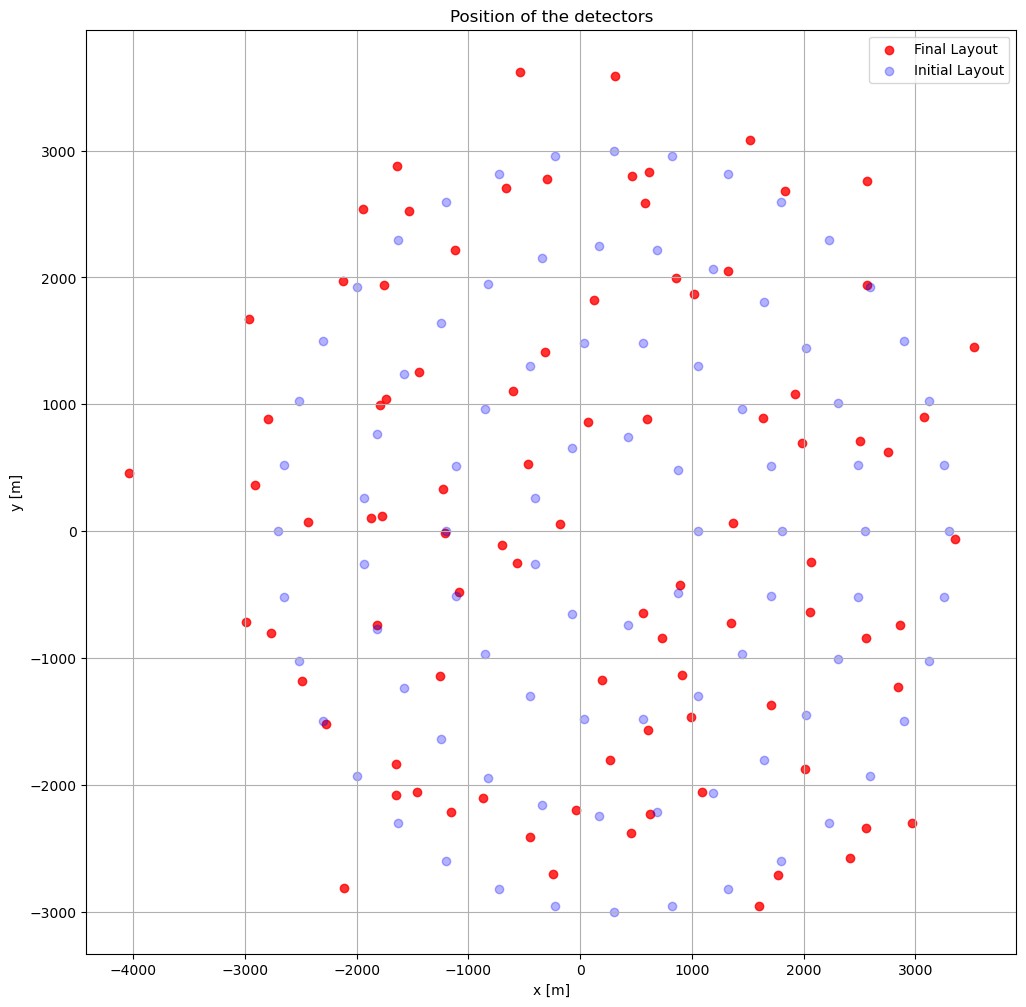

In [ ]:
a, b = Layouts(n_detectors=Nunits, n_rings=n_rings, radius=3000)

plt.figure(figsize=[12, 12])
plt.scatter(
    x_det_opt.detach().cpu(), 
    y_det_opt.detach().cpu(), 
    color="red", alpha=.8, label="Final Layout"
    )
plt.scatter(a, b, color="blue", alpha=.3, label="Initial Layout")
plt.grid(); plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title("Position of the detectors"); plt.legend()
plt.show()

In [ ]:
utility_path = Path(f"{output_dir}/Python_Layout/Utilities.txt")

if utility_path.exists():
    u_t = np.loadtxt(utility_path)
    u_t = np.append(u_t, np.array(U_vals).ravel())
    np.savetxt(utility_path, u_t)
else:
    u_t = U_vals
    np.savetxt(utility_path, u_t)

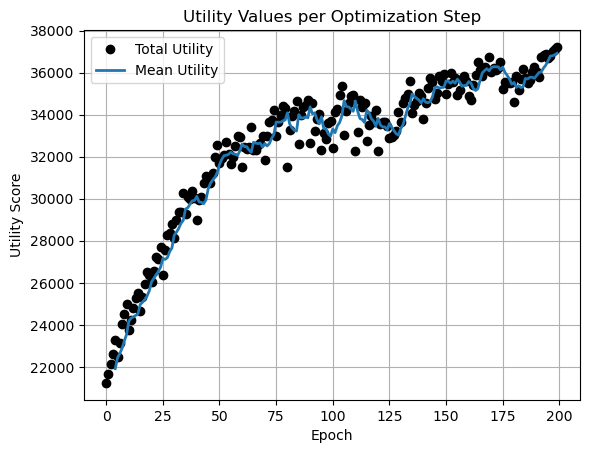

In [ ]:
mean_ut = [np.mean(u_t[i - 4: i]) for i in range(4, len(u_t))]

plt.plot(u_t, color="black", linestyle="none", marker="o", linewidth=.5, label="Total Utility")
plt.plot(np.arange(4, len(u_t)), mean_ut, linestyle="-", linewidth=2, label="Mean Utility")
plt.legend(); plt.grid()
plt.xlabel("Epoch"); plt.ylabel("Utility Score")
# plt.ylim((-0.1, 1000.2))
plt.title("Utility Values per Optimization Step")
plt.show()

## Evaluate Reconstruction (end)

In [ ]:
x,y = x_det_opt,y_det_opt
with torch.no_grad():
    N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a, _ = generate_showers(x, y, False, number_of_showers=Ntest, use_cache=True)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Ntest, -1)
y_exp = y.unsqueeze(0).expand(Ntest, -1)

x0_exp = x0.unsqueeze(1).expand(-1, Nunits)
y0_exp = y0.unsqueeze(1).expand(-1, Nunits)

inputs_test = torch.stack([x_exp, y_exp, N, T, x0_exp, y0_exp], dim=2).float()
inputs_test = (inputs_test - input_mean) / input_std  # add this line
labels_test = torch.stack([E_norm, theta_norm, phi_norm], dim=1).float()

Loading cached showers from ./outputs/NN_Files_30_20k_new_model/cashed_showers_300.pt


In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1).to(device)).cpu()

In [ ]:
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 0], outputs[:, 1], outputs[:, 2])

E_p, E_r = E_pred.cpu(), energy.cpu()
Th_r, Th_p = th.cpu(), theta_pred.cpu()
Ph_r, Ph_p = ph.cpu(), phi_pred.cpu()

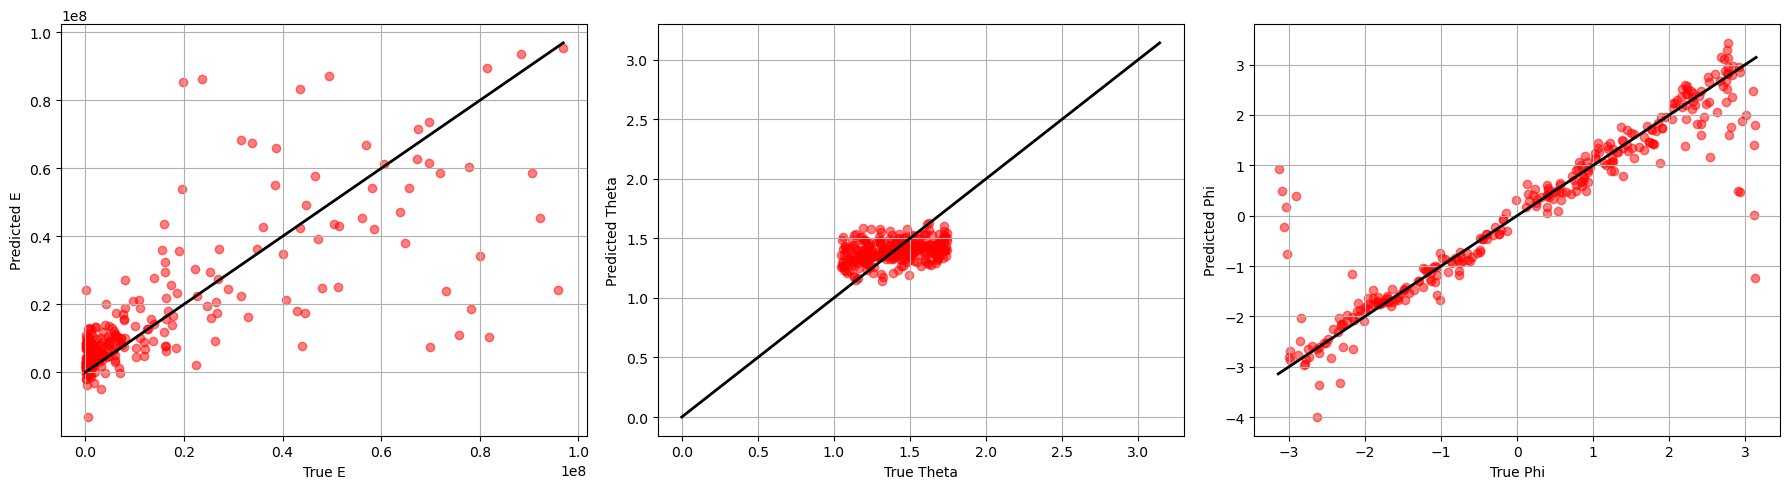

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(E_r.cpu(), E_p.cpu(), alpha=.5, color="r")
axes[0].plot([0, E_r.max().cpu()], [0, E_r.max().cpu()], "k-", lw=2)
axes[0].set_xlabel("True E"); axes[0].set_ylabel("Predicted E"); axes[0].grid()

axes[1].scatter(Th_r.cpu(), Th_p.detach().cpu(), alpha=.5, color="r")
axes[1].plot([0, np.pi], [0, np.pi], "k-", lw=2)
axes[1].set_xlabel("True Theta"); axes[1].set_ylabel("Predicted Theta"); axes[1].grid()

axes[2].scatter(Ph_r.cpu(), Ph_p.detach().cpu(), alpha=.5, color="r")
axes[2].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[2].set_xlabel("True Phi"); axes[2].set_ylabel("Predicted Phi"); axes[2].grid()

plt.tight_layout(); plt.show()


TAMBO KPI
- efficiency, fraction of particles detected, 
- they don't care about Energy
- direction of the primary particle